In [1]:
# ============================================
# 0. Setup
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình plot
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Đọc dữ liệu (chú ý encoding cp1252)
df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding="cp1252", low_memory=False)

print("Shape:", df.shape)
df.head(3)


Shape: (26476, 50)


,Type,Days for shipping_real,Days for shipment_scheduled,Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Name,Product Price,Product Status,shipping date,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,NaN,1360.0,73.0,NaN,Smart watch,327.75,0.0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,NaN,1360.0,73.0,NaN,Smart watch,327.75,0.0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,NaN,1360.0,73.0,NaN,Smart watch,327.75,0.0,1/17/2018 12:06,Standard Class


In [2]:
# Info + missing values
df.info()
df.isna().sum().sort_values(ascending=False).head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26476 entries, 0 to 26475
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Type                         26476 non-null  object 
 1   Days for shipping_real       26476 non-null  int64  
 2   Days for shipment_scheduled  26476 non-null  int64  
 3   Benefit per order            26476 non-null  float64
 4   Sales per customer           26476 non-null  float64
 5   Delivery Status              26476 non-null  object 
 6   Late_delivery_risk           26476 non-null  int64  
 7   Category Id                  26476 non-null  int64  
 8   Category Name                26476 non-null  object 
 9   Customer City                26476 non-null  object 
 10  Customer Country             26476 non-null  object 
 11  Customer Fname               26476 non-null  object 
 12  Customer Id                  26476 non-null  int64  
 13  Customer Lname  

,0
Product Description,26476
Order Zipcode,22948
order date,1
Order Id,1
Order Item Total,1
Order Item Profit Ratio,1
Order Item Discount,1
Order Item Product Price,1
Order Item Id,1
Order Item Discount Rate,1


In [3]:
# Strip khoảng trắng, đổi snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Chuyển datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["shipping_date"] = pd.to_datetime(df["shipping_date"], errors="coerce")


In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T.sort_values("mean").head(15)


,count,mean,std,min,25%,50%,75%,max
longitude,26475.0,-83.895428,21.581857,-158.025986,-97.499138,-75.108467,-66.370575,115.049789
product_status,26475.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
order_item_discount_rate,26475.0,0.102314,0.070757,0.000000,0.040000,0.100000,0.160000,0.250000
order_item_profit_ratio,26475.0,0.122052,0.465182,-2.750000,0.080000,0.270000,0.360000,0.500000
late_delivery_risk,26476.0,0.560545,0.496330,0.000000,0.000000,1.000000,1.000000,1.000000
order_item_quantity,26475.0,2.412389,1.543085,1.000000,1.000000,2.000000,4.000000,5.000000
days_for_shipment_scheduled,26476.0,2.982512,1.353635,0.000000,2.000000,4.000000,4.000000,4.000000
days_for_shipping_real,26476.0,3.497772,1.577759,0.000000,2.000000,3.000000,5.000000,6.000000
department_id,26476.0,4.742748,1.588282,2.000000,4.000000,4.000000,5.000000,12.000000
order_item_discount,26475.0,20.809098,22.880077,0.000000,5.400000,14.000000,28.799999,500.000000


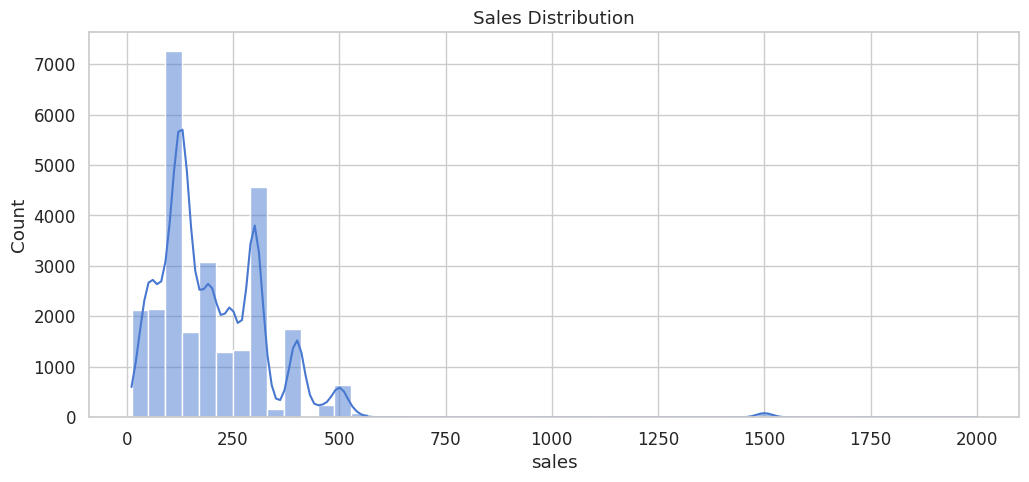

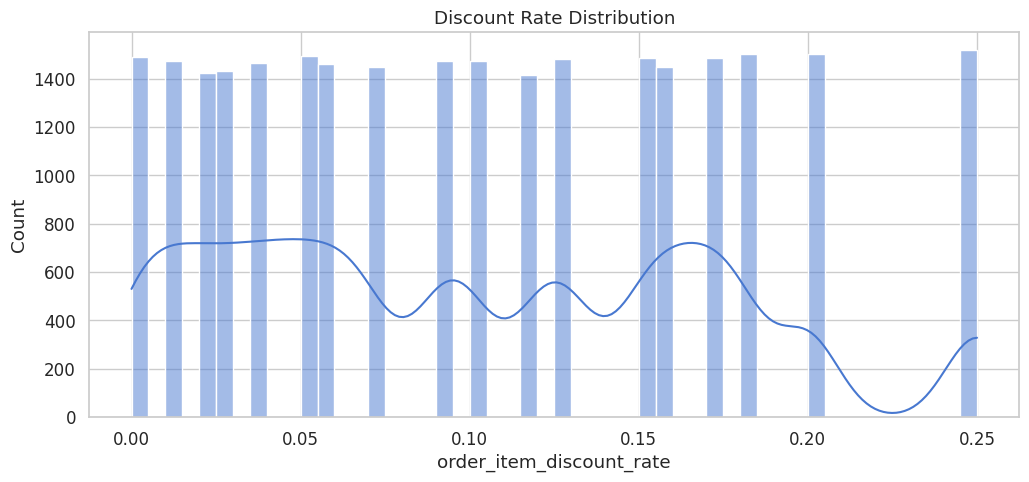

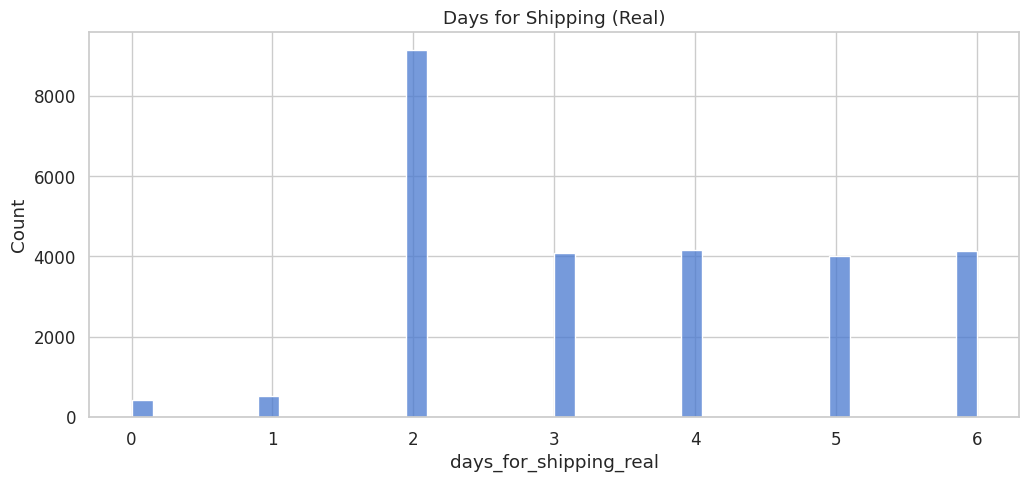

In [5]:
plt.figure(figsize=(12,5))
sns.histplot(df["sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df["order_item_discount_rate"], bins=50, kde=True)
plt.title("Discount Rate Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df["days_for_shipping_real"], bins=40, kde=False)
plt.title("Days for Shipping (Real)")
plt.show()


In [6]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in ["shipping_mode","market","order_region","category_name","customer_segment"]:
    print(col, ":", df[col].nunique(), "unique values")
    print(df[col].value_counts(normalize=True).head(), "\n")


shipping_mode : 4 unique values
shipping_mode
Standard Class    0.618281
First Class       0.183418
Second Class      0.163022
Same Day          0.035279
Name: proportion, dtype: float64 

market : 5 unique values
market
Europe          0.284306
LATAM           0.268933
Pacific Asia    0.249556
USCA            0.138281
Africa          0.058924
Name: proportion, dtype: float64 

order_region : 23 unique values
order_region
Western Europe     0.153919
Central America    0.148933
South America      0.077923
Oceania            0.062852
Southeast Asia     0.058130
Name: proportion, dtype: float64 

category_name : 41 unique values
category_name
Cleats              0.190134
Women's Apparel     0.167359
Men's Footwear      0.144470
Cardio Equipment    0.101715
Camping & Hiking    0.090875
Name: proportion, dtype: float64 

customer_segment : 3 unique values
customer_segment
Consumer       0.492370
Corporate      0.394924
Home Office    0.112706
Name: proportion, dtype: float64 



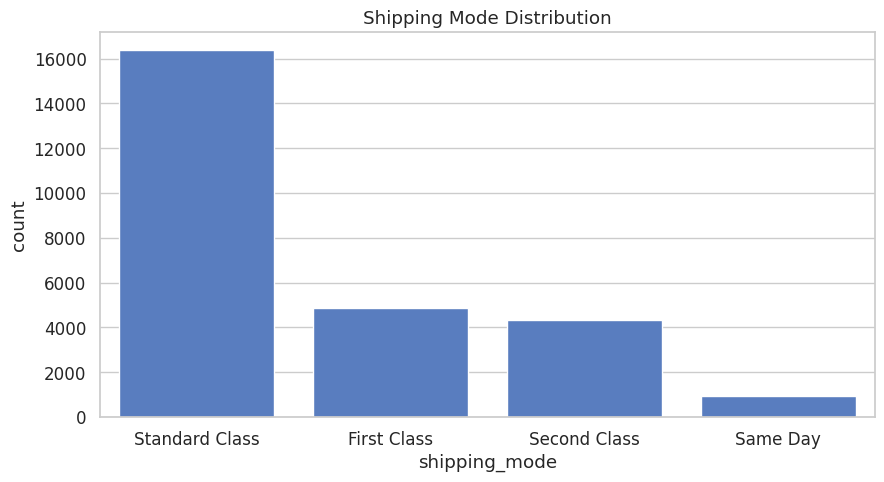

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="shipping_mode", order=df["shipping_mode"].value_counts().index)
plt.title("Shipping Mode Distribution")
plt.show()


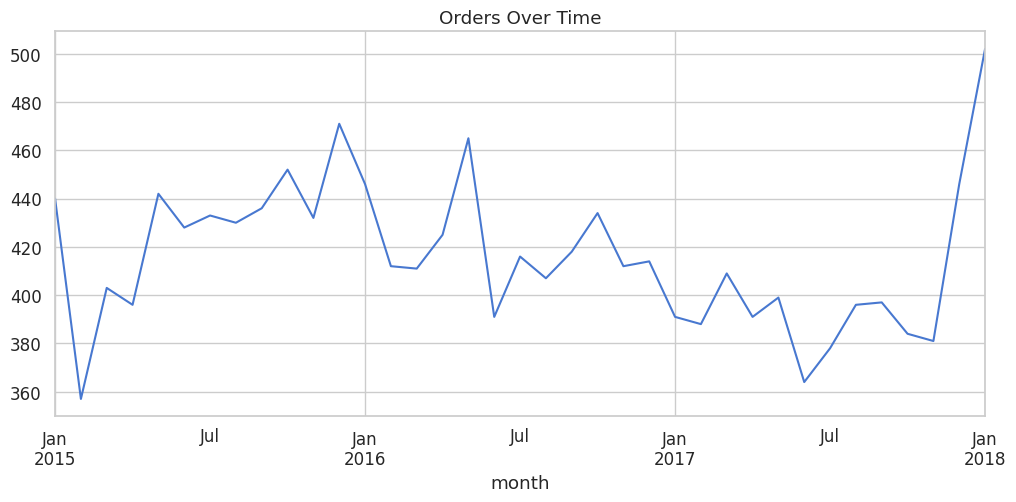

In [8]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.to_period("M")
df["weekday"] = df["order_date"].dt.day_name()

# Đơn hàng theo thời gian
orders_by_month = df.groupby("month")["order_id"].nunique()
orders_by_month.plot(kind="line", figsize=(12,5), title="Orders Over Time")
plt.show()


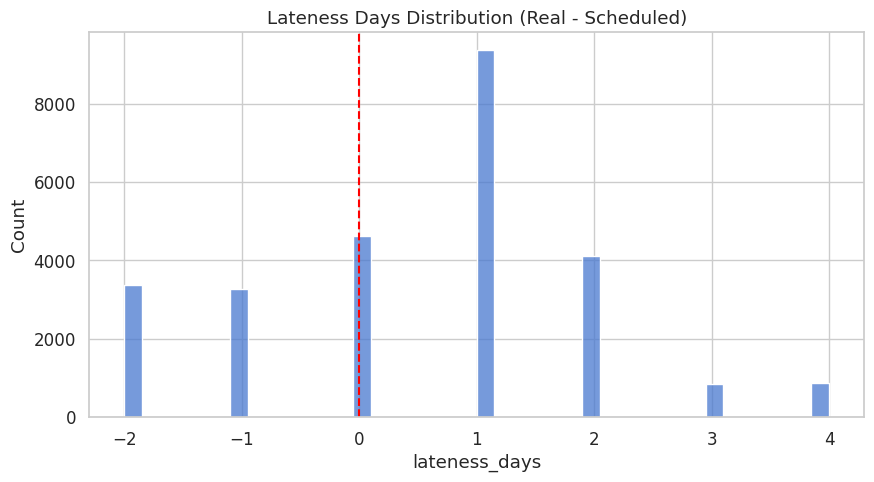

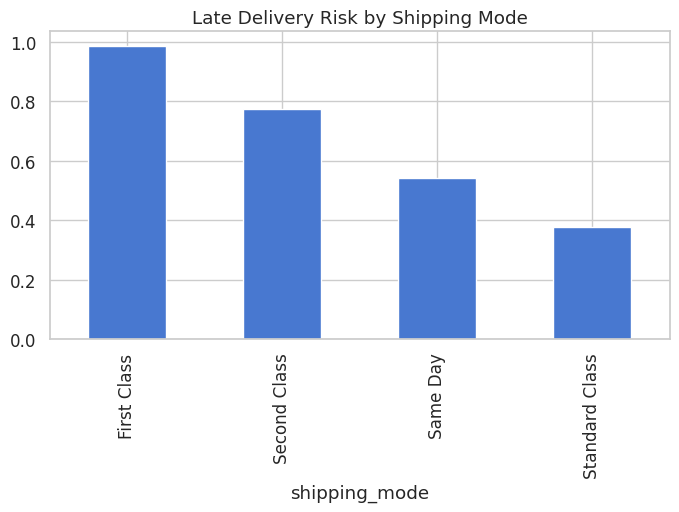

In [9]:
df["lateness_days"] = df["days_for_shipping_real"] - df["days_for_shipment_scheduled"]

plt.figure(figsize=(10,5))
sns.histplot(df["lateness_days"], bins=40, kde=False)
plt.axvline(0, color="red", linestyle="--")
plt.title("Lateness Days Distribution (Real - Scheduled)")
plt.show()

# Late risk theo Shipping Mode
late_by_mode = df.groupby("shipping_mode")["late_delivery_risk"].mean().sort_values(ascending=False)
late_by_mode.plot(kind="bar", figsize=(8,4), title="Late Delivery Risk by Shipping Mode")
plt.show()


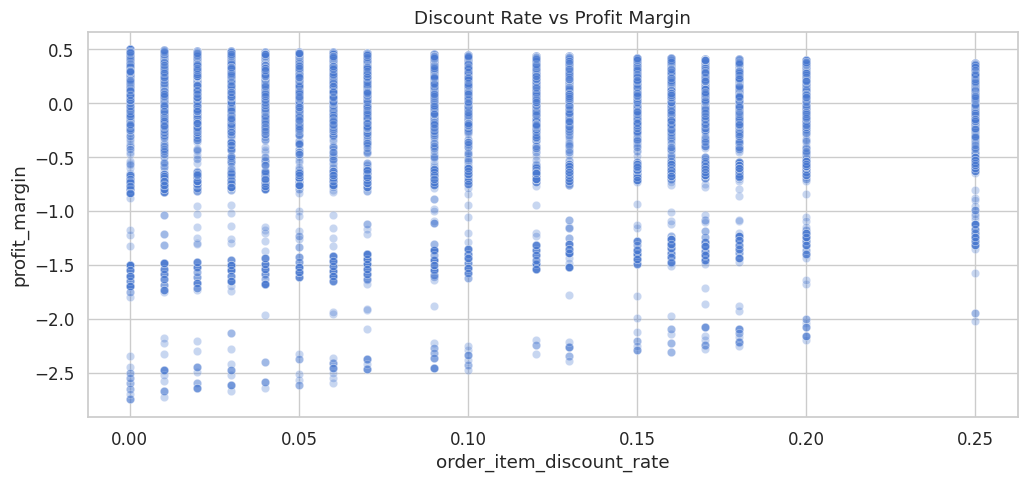

In [10]:
df["profit_margin"] = df["order_profit_per_order"] / df["sales"]

plt.figure(figsize=(12,5))
sns.scatterplot(data=df, x="order_item_discount_rate", y="profit_margin", alpha=0.3)
plt.title("Discount Rate vs Profit Margin")
plt.show()


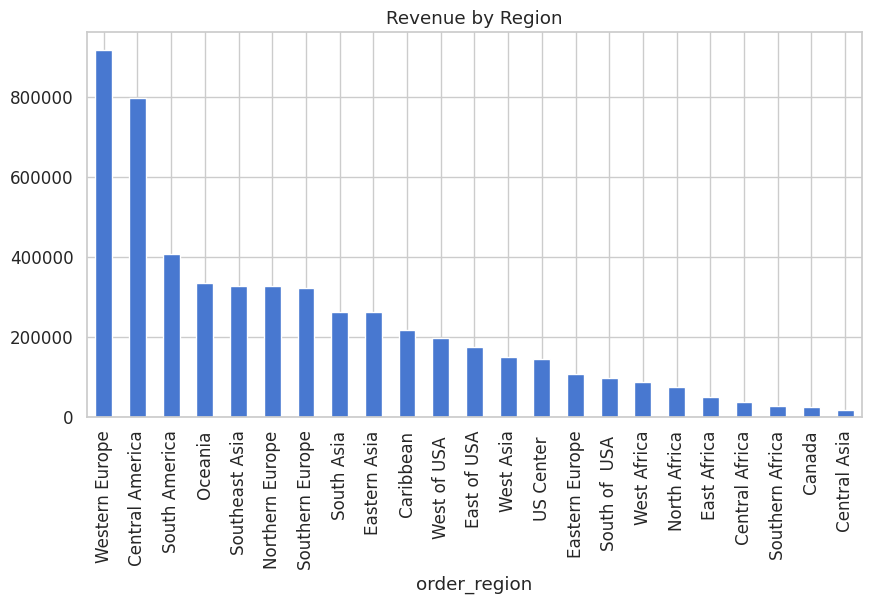

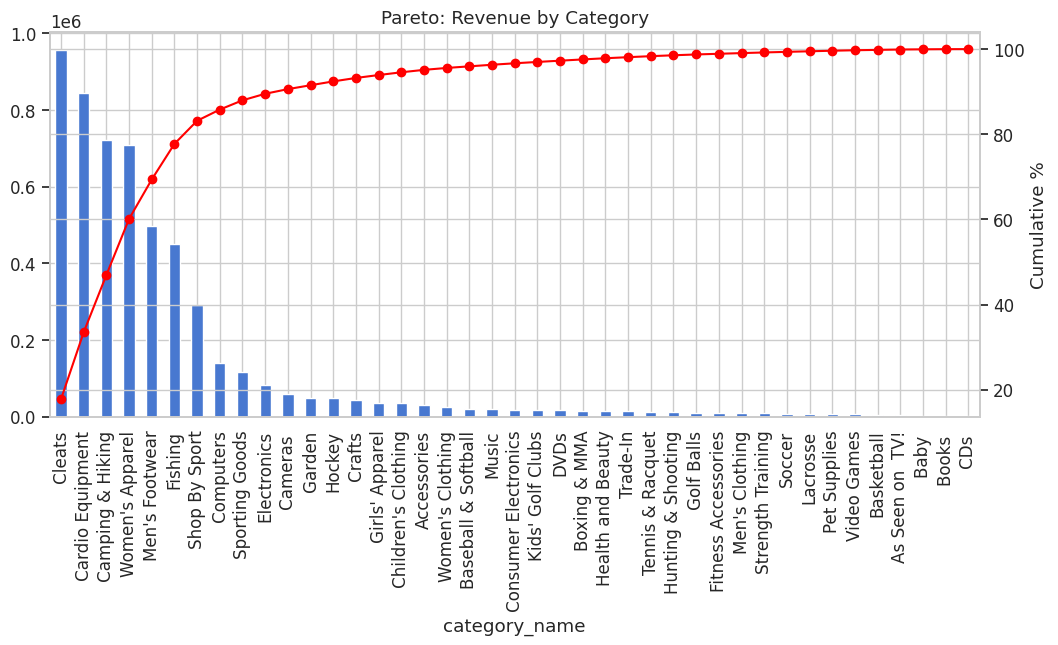

In [11]:
# Doanh thu theo region
revenue_region = df.groupby("order_region")["sales"].sum().sort_values(ascending=False)
revenue_region.plot(kind="bar", figsize=(10,5), title="Revenue by Region")
plt.show()

# Pareto chart cho Category
revenue_cat = df.groupby("category_name")["sales"].sum().sort_values(ascending=False)
cum_pct = revenue_cat.cumsum()/revenue_cat.sum()*100
ax = revenue_cat.plot(kind="bar", figsize=(12,5))
ax2 = ax.twinx()
cum_pct.plot(marker="o", color="red", ax=ax2)
ax.set_title("Pareto: Revenue by Category")
ax2.set_ylabel("Cumulative %")
plt.show()


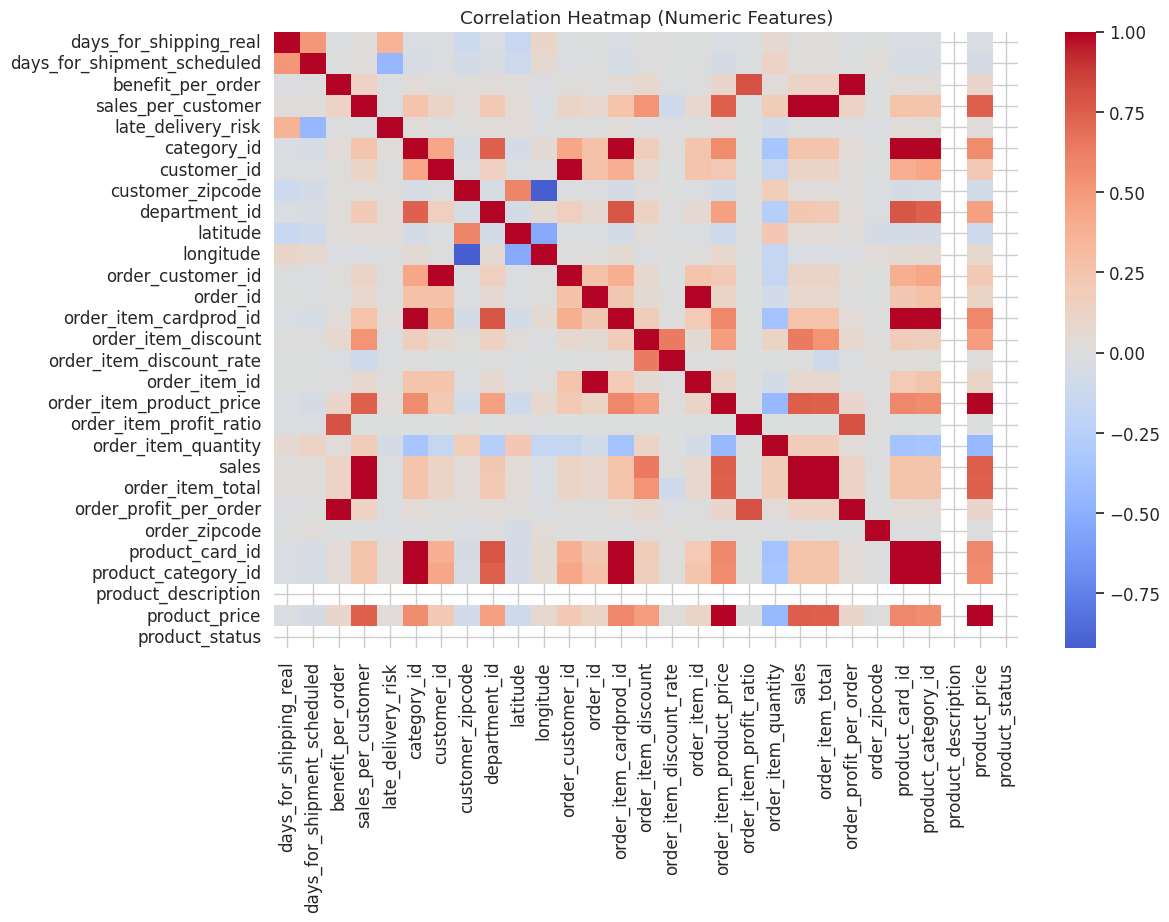

In [12]:
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()
